# MLSA-Project
This notebook contains the complete pipeline for training, evaluating, and testing a fine-tuned CodeT5-small model on the CodeSearchNet dataset. The project is structured modularly, relying on YAML configuration files to ensure strict separation between code logic and hyperparameters, guaranteeing full reproducibility.

## Environment Setup and Repository
We set up the workspace by cloning the project repository. We ensure any previous instances are removed to start with a clean, updated environment.

In [1]:
# Clean up previous clone to allow a fresh pull
%cd /content
!rm -rf MLSA-project

# Clone and enter directory
!git clone https://github.com/emanuelebrizzi/MLSA-project.git
%cd MLSA-project

/content
Cloning into 'MLSA-project'...
remote: Enumerating objects: 381, done.
remote: Counting objects: 100% (381/381), done.
remote: Compressing objects: 100% (223/223), done.
remote: Total 381 (delta 202), reused 316 (delta 142), pack-reused 0 (from 0)
Receiving objects: 100% (381/381), 75.64 KiB | 3.60 MiB/s, done.
Resolving deltas: 100% (202/202), done.
/content/MLSA-project


### Dependency Management
To avoid known compatibility issues between the `Seq2SeqTrainer` and the pre-installed libraries on Google Colab, we must remove the default `peft` package before installing our exact pinned requirements.

In [2]:
# Remove Colab's pre-installed peft to prevent accelerate dependency conflicts
!pip uninstall -y peft

# Install pinned project dependencies
!pip install -r requirements.txt


Found existing installation: peft 0.20.0
Uninstalling peft-0.20.0:
  Successfully uninstalled peft-0.20.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 14.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 14.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 123.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.9 MB

## Experiment Studies
In this section, we train three model variants to evaluate the impact of individual hyperparameters (context size and learning rate) on the final performance.

### Experiment: Short Context (colab_test1.yaml)
Configuration with a reduced context of 128/32 tokens to measure the impact of restricting the information window.

In [ ]:
# Start training with reduced context (128 input tokens, 32 target tokens)
!python scripts/train.py --config configs/colab_test1.yaml

=== Starting experiment: codet5_colab_configuration ===
Configuration file in use: configs/colab_test1.yaml
Loading CodeSearchNet dataset (language: Python)...
Cleaning and normalizing text fields across splits...
Filtering invalid or overly short sequences...
Shuffling training split...
Loading tokenizer for Salesforce/codet5-small...
/usr/local/lib/python3.13/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Tokenizing the dataset...
Map: 100% 411264/411264 [08:37<00:00, 794.98 examples/s]
Tokenizing the dataset...
Map: 100% 22578/22578 [00:29<00:00, 775.63 examples/s] 
Loading pre-trained model weights: Salesforce/codet5-small...
Training will be limited to max_steps: 600
/usr/local/lib/python3.13/dist-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following a

### Experiment: Baseline (colab_text2.yaml)
Our reference configuration with optimal context (256/64 tokens) and standard learning rate at 3e-4.

In [ ]:
# Full fine-tuning run (Targeted for GPU / Colab execution)
!python scripts/train.py --config configs/colab_text2.yaml

=== Starting experiment: codet5_colab_configuration ===
Configuration file in use: configs/colab_text2.yaml
Loading CodeSearchNet dataset (language: Python)...
Cleaning and normalizing text fields across splits...
Filtering invalid or overly short sequences...
Shuffling training split...
Loading tokenizer for Salesforce/codet5-small...
/usr/local/lib/python3.13/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Tokenizing the dataset...
Map: 100% 411264/411264 [08:43<00:00, 786.17 examples/s]
Tokenizing the dataset...
Map: 100% 22578/22578 [00:29<00:00, 754.34 examples/s]
Loading pre-trained model weights: Salesforce/codet5-small...
Training will be limited to max_steps: 600
/usr/local/lib/python3.13/dist-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following ar

### Experiment: Low LR (colab_text3.yaml)
Variant with a reduced Learning Rate of 5e-5 (on a 256/64 context) to test the model's convergence speed and effectiveness.

In [ ]:
# Start training with a reduced learning rate
!python scripts/train.py --config configs/colab_text3.yaml

=== Starting experiment: codet5_colab_configuration ===
Configuration file in use: configs/colab_text3.yaml
Loading CodeSearchNet dataset (language: Python)...
Cleaning and normalizing text fields across splits...
Filtering invalid or overly short sequences...
Shuffling training split...
Loading tokenizer for Salesforce/codet5-small...
/usr/local/lib/python3.13/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Tokenizing the dataset...
Tokenizing the dataset...
Loading pre-trained model weights: Salesforce/codet5-small...
Training will be limited to max_steps: 600
/usr/local/lib/python3.13/dist-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_ba

## Results Comparison
Reading the CSV log where the final metrics of each experiment were automatically saved.

In [3]:
# Display the summary table of the logs
!cat logs/experiments_log.csv

Timestamp,Config,Notes,Eval Loss,SacreBLEU,ROUGE-L
2026-09-13 20:48:44,configs/colab_test1.yaml,max_length: 32 max_input_length: 128 max_target_length: 32,1.4563,12.6485,0.3347
2026-09-13 22:06:30,configs/colab_text2.yaml,max_length: 64 max_input_length: 256 max_target_length: 64,0.8219,10.0235,0.3305
2026-09-13 23:05:17,configs/colab_text3.yaml,learning_rate: 5.0e-5 max_length: 64 max_input_length: 256 max_target_length: 64,0.8383,9.0532,0.3248

Chart generated successfully and saved as 'ablation_metrics.png'


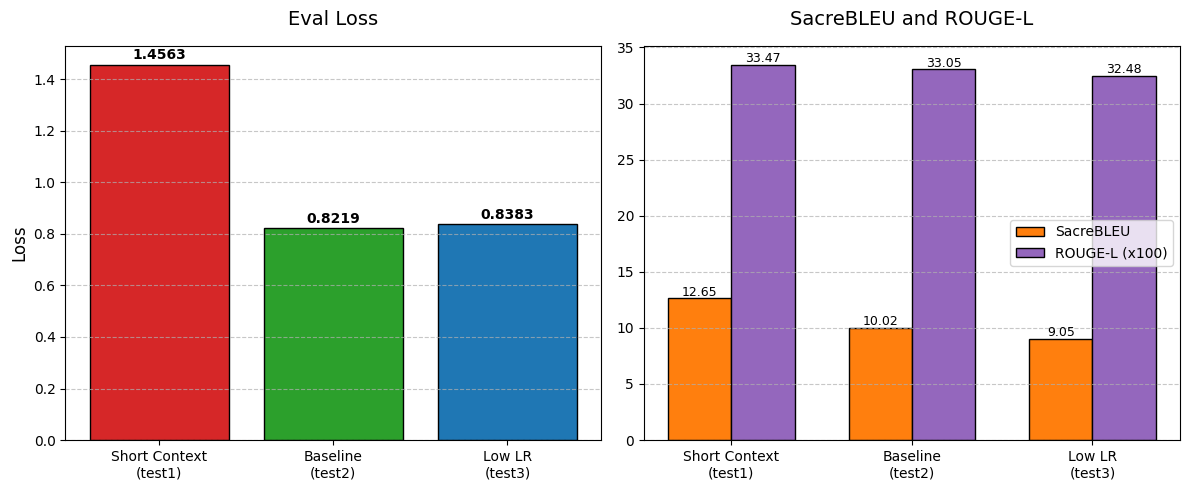

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load data from the CSV file
csv_path = 'logs/experiments_log.csv'
df = pd.read_csv(csv_path)

# Helper function to map YAML filenames to chart labels
def get_label(config_str):
    if 'test2' in config_str or 'text2' in config_str:
        return 'Baseline\n(test2)'
    elif 'test1' in config_str:
        return 'Short Context\n(test1)'
    elif 'test3' in config_str or 'text3' in config_str:
        return 'Low LR\n(test3)'
    return config_str.split('/')[-1]

# Extract data dynamically
experiments = [get_label(c) for c in df['Config']]
eval_loss = df['Eval Loss'].round(4).tolist()
sacrebleu = df['SacreBLEU'].round(2).tolist()
# ROUGE-L is multiplied by 100 to align visually with the SacreBLEU scale
rouge_l = (df['ROUGE-L'] * 100).round(2).tolist()

x = np.arange(len(experiments))
width = 0.35

# Set custom colors for the Loss chart based on the experiment type
loss_colors = []
for label in experiments:
    if 'Baseline' in label:
        loss_colors.append('#2ca02c')
    elif 'Short Context' in label:
        loss_colors.append('#d62728')
    else:
        loss_colors.append('#1f77b4')

# Create the figure with 2 side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Chart A: Eval Loss (Lower is better)
ax1.bar(experiments, eval_loss, color=loss_colors, edgecolor='black')
ax1.set_title('Eval Loss', fontsize=14, pad=15)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of the Loss bars
for i, v in enumerate(eval_loss):
    ax1.text(i, v + 0.02, str(v), ha='center', fontweight='bold')

# Chart B: Textual Metrics (Higher is better)
rects1 = ax2.bar(x - width/2, sacrebleu, width, label='SacreBLEU', color='#ff7f0e', edgecolor='black')
rects2 = ax2.bar(x + width/2, rouge_l, width, label='ROUGE-L (x100)', color='#9467bd', edgecolor='black')

ax2.set_title('SacreBLEU and ROUGE-L', fontsize=14, pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(experiments)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of the bars (SacreBLEU)
for i, v in enumerate(sacrebleu):
    ax2.text(i - width/2, v + 0.2, str(v), ha='center', fontsize=9)

# Add values on top of the bars (ROUGE-L)
for i, v in enumerate(rouge_l):
    ax2.text(i + width/2, v + 0.2, str(v), ha='center', fontsize=9)

# Format and save
plt.tight_layout()
plt.savefig('ablation_metrics.png', dpi=300, bbox_inches='tight')
print("Chart generated successfully and saved as 'ablation_metrics.png'")
plt.show()

## Final Training (Optimal Model)

In [5]:
# Execute the final training with the definitive configuration colab.yaml
!python scripts/train.py --config configs/colab.yaml

=== Starting experiment: codet5_colab_configuration ===
Configuration file in use: configs/colab.yaml
Loading CodeSearchNet dataset (language: Python)...
README.md: 14.1kB [00:00, 46.1MB/s]
python/train-00000-of-00001.parquet: 100% 522M/522M [00:06<00:00, 79.9MB/s]
python/test-00000-of-00001.parquet: 100% 28.7M/28.7M [00:00<00:00, 31.9MB/s]
python/validation-00000-of-00001.parquet: 100% 30.7M/30.7M [00:00<00:00, 39.4MB/s]
Generating train split: 100% 412178/412178 [00:10<00:00, 39472.90 examples/s]
Generating test split: 100% 22176/22176 [00:00<00:00, 42897.38 examples/s]
Generating validation split: 100% 23107/23107 [00:00<00:00, 53783.21 examples/s]
Cleaning and normalizing text fields across splits...
Normalizing text and removing docstrings: 100% 412178/412178 [00:27<00:00, 15250.39 examples/s]
Normalizing text and removing docstrings: 100% 22176/22176 [00:01<00:00, 15734.25 examples/s]
Normalizing text and removing docstrings: 100% 23107/23107 [00:01<00:00, 14718.67 examples/s]
Fi

## Evaluation
Quantitative evaluation phase of the final model on the test set and docstring generation testing.

In [6]:
# Evaluation against the test partition
!python scripts/evaluation.py --checkpoint checkpoints/colab_run/final_model --config configs/colab.yaml

Starting standalone evaluation for checkpoint: checkpoints/colab_run/final_model
Loading CodeSearchNet dataset (language: Python)...
Cleaning and normalizing text fields across splits...
Filtering invalid or overly short sequences...
Shuffling training split...
Loading tokenizer for checkpoints/colab_run/final_model...
Tokenizing the dataset...
Map: 100% 22138/22138 [00:28<00:00, 789.82 examples/s]
/usr/local/lib/python3.13/dist-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/accelerate/accelerator.py:469: FutureWarning: `torch.cud

## Summarize
To conclude the pipeline, we test the final model's generative capabilities on a raw, unseen snippet of Python code.

In [8]:
# Interactive inference verification
!python scripts/summarize.py --checkpoint checkpoints/colab_run/final_model --input "def is_even(n): return n % 2 == 0"

Loading model on cuda...

--- INPUT CODE ---
def is_even(n): return n % 2 == 0
------------------

--- GENERATED SUMMARY ---
returns true if n is even.
-------------------------
